# Proyecto Integrador Módulo 4 – Machine Learning
## Avance 3: Aprendizaje No Supervisado
**FinanceGuard - Predicción de Churn Bancario**

### Rol del aprendizaje no supervisado dentro del proyecto integral

El aprendizaje no supervisado cumple un rol **exploratorio y complementario** dentro del Proyecto Integrador de Machine Learning. A diferencia de los modelos supervisados, cuyo objetivo es predecir explícitamente la probabilidad de churn a partir de una variable objetivo conocida, las técnicas no supervisadas permiten **descubrir patrones ocultos y estructuras internas** en los datos sin utilizar etiquetas.

En el contexto del churn bancario, este enfoque resulta especialmente relevante porque clientes con el mismo resultado final (abandono o permanencia) pueden presentar **comportamientos, perfiles y motivaciones muy diferentes**. El clustering permite agrupar clientes según similitudes en sus características demográficas, financieras y de uso de productos, ofreciendo una visión más granular del fenómeno que la predicción binaria por sí sola.

De esta manera, el aprendizaje no supervisado no reemplaza a los modelos predictivos desarrollados en otros avances, sino que los **enriquece**, aportando interpretabilidad, mejor comprensión del dominio y una base sólida para mejorar el feature engineering y la toma de decisiones estratégicas.

### Relación entre segmentación y estrategias de retención

La segmentación de clientes es un paso fundamental para traducir los resultados analíticos en **acciones concretas de negocio**. Identificar clusters de clientes con comportamientos similares permite diseñar **estrategias de retención diferenciadas**, en lugar de aplicar enfoques homogéneos que suelen ser menos eficientes y más costosos.

Cada segmento puede presentar necesidades y riesgos distintos: algunos clusters pueden concentrar clientes de alto valor con señales tempranas de abandono, mientras que otros pueden agrupar clientes con bajo engagement o sensibilidad al precio. Reconocer estas diferencias habilita estrategias de retención **focalizadas y proactivas**, como incentivos personalizados, mejoras en la experiencia digital o propuestas de productos específicas.

Además, los segmentos identificados mediante clustering pueden incorporarse como **nuevas variables explicativas** en modelos supervisados posteriores. Esto permite construir modelos de churn más sensibles a las diferencias estructurales entre tipos de clientes, reforzando el vínculo entre análisis exploratorio, modelado predictivo y decisiones estratégicas del banco.

---

---


## 1. Importación de librerías

In [1]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Búsqueda de hiperparámetros / soporte para DBSCAN
from sklearn.neighbors import NearestNeighbors

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Métricas de evaluación no supervisada
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder

# Reproducibilidad y warnings
# import warnings
# warnings.filterwarnings('ignore')


## 2. Carga del dataset y EDA

In [2]:
# 1. Cargar dataset
df = pd.read_csv("Churn_Modelling.csv")

# 2. Shape del dataset
print("Shape del dataset:", df.shape)

# 3. Tipos de variables
print("\nTipos de variables:")
print(df.dtypes)

# 4. Nulos
print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())

# 5. Duplicados
print("\nCantidad de filas duplicadas:", df.duplicated().sum())

# 6. Primeras filas para inspección rápida
print("\nPrimeras 5 filas:")
print(df.head())

Shape del dataset: (10000, 14)

Tipos de variables:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Cantidad de valores nulos por columna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Cantidad de filas duplicadas: 0

Primeras 5 filas:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1        

### EDA - Resultados iniciales

- **Shape del dataset**: El archivo contiene 10,000 filas y 14 columnas, lo que confirma la escala mencionada en la consigna.  
- **Tipos de variables**: Se observan columnas numéricas (ej. `CreditScore`, `Age`, `Balance`, `EstimatedSalary`) y categóricas (ej. `Geography`, `Gender`).  
- **Valores nulos**: No se detectaron valores faltantes en ninguna columna, lo que simplifica el preprocesamiento.  
- **Duplicados**: No se encontraron filas duplicadas, por lo que no es necesario aplicar limpieza adicional en este aspecto.  
- **Primeras filas**: La estructura coincide con un dataset de clientes bancarios, incluyendo identificadores (`RowNumber`, `CustomerId`, `Surname`) y variables relevantes para churn.

Con este chequeo rápido podemos avanzar directamente al preprocesamiento y clustering, ya que no hay problemas de nulos ni duplicados.  
El foco estará en **evitar data leakage** (ej. no usar `Exited` en transformaciones previas al modelado) y en estandarizar variables numéricas antes de aplicar algoritmos de clustering.

---

---


## 3. Preprocesamiento

In [3]:
# 1. Selección de variables numéricas relevantes
# (excluimos identificadores y la variable target 'Exited' para evitar data leakage)
features = df.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])

# 2. Identificar columnas numéricas y categóricas
num_cols = features.select_dtypes(include=["int64", "float64"]).columns
cat_cols = features.select_dtypes(include=["object"]).columns

print("Columnas numéricas:", list(num_cols))
print("Columnas categóricas:", list(cat_cols))

# 3. Preprocesamiento:
# - Escalamos las numéricas con StandardScaler
# - OneHotEncoder para las categóricas
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

# 4. Transformar dataset
X_transformed = preprocessor.fit_transform(features)

print("\nShape de la matriz transformada:", X_transformed.shape)

Columnas numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Columnas categóricas: ['Geography', 'Gender']

Shape de la matriz transformada: (10000, 11)


> En este avance de aprendizaje no supervisado, el preprocesamiento se aplica a todo el dataset porque no existe variable objetivo en el clustering.

### 3.1. Ver nombres de las columnas generadas por el OneHotEncoder

In [4]:
encoder = preprocessor.named_transformers_['cat']
encoded_cols = encoder.get_feature_names_out(cat_cols)

print("Columnas codificadas:", encoded_cols)

Columnas codificadas: ['Geography_Germany' 'Geography_Spain' 'Gender_Male']


### Preprocesamiento - Resultados

- **Selección de variables**:  
  - Se eliminaron `RowNumber`, `CustomerId` y `Surname` porque son identificadores sin valor predictivo.  
  - Se eliminó `Exited` porque es la **variable objetivo** del problema de churn.  
    - Justificación: en un análisis no supervisado como clustering, incluir la variable target generaría **data leakage**, ya que el algoritmo estaría “viendo” la respuesta que después queremos predecir.  
    - Por eso se excluye antes de cualquier transformación.

- **Columnas numéricas seleccionadas**: `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`.  
- **Columnas categóricas seleccionadas**: `Geography`, `Gender`.  

- **Transformaciones aplicadas**:  
  - Numéricas → escaladas con `StandardScaler` para evitar sesgos por magnitudes distintas.  
  - Categóricas → codificadas con `OneHotEncoder (drop="first")`, generando variables dummy sin colinealidad perfecta.  

- **Shape final de la matriz**: `(10000, 11)`.  
  - 8 columnas numéricas transformadas + 3 columnas dummy de las categóricas.  

Con esto confirmamos que las variables están listas para aplicar algoritmos de clustering sin riesgo de *data leakage* ni sesgos por escala o codificación.

---

### 3.2 Multicolinealidad

En este proyecto no se realizó eliminación de columnas altamente correlacionadas.  
La decisión se fundamenta en que, en el contexto de **aprendizaje no supervisado**, la multicolinealidad no representa un problema estadístico crítico como en modelos lineales supervisados. Algoritmos como **K-Means** y **DBSCAN** se basan en medidas de distancia y pueden manejar variables correlacionadas sin comprometer la validez matemática del procedimiento. Además, la etapa de **reducción de dimensionalidad (PCA)** sintetiza automáticamente las correlaciones entre variables, capturando la varianza compartida en componentes principales.

No obstante, se reconoce que en ciertos casos la eliminación o transformación de variables colineales puede mejorar la **interpretabilidad de los clusters** y reducir el impacto de variables redundantes en la formación de grupos. Por ejemplo:
- Cuando dos variables aportan información casi idéntica, una puede dominar la distancia euclídea y sesgar la segmentación.  
- En modelos supervisados posteriores (ej. regresión logística), la multicolinealidad sí puede afectar la estabilidad de los coeficientes y la claridad de la interpretación.  

En este trabajo se optó por conservar todas las variables en el preprocesamiento, dejando que PCA gestione la redundancia y priorizando la **interpretabilidad posterior en términos de negocio** (edad, balance, ingresos, etc.).

---

---


## 4. Clústering con K-Means

### 4.1. Introducción a K-Means

**K-Means** es uno de los algoritmos de clustering más utilizados en aprendizaje no supervisado.  
Su objetivo es dividir un conjunto de datos en *K* grupos (clusters) de manera que los puntos dentro de cada grupo sean lo más similares posible entre sí y lo más distintos posible de los puntos de otros grupos.

- **Centroides**:  
  Cada cluster se representa por un centroide, que es el promedio de las observaciones asignadas a ese grupo. Los centroides se actualizan en cada iteración.

- **Iteraciones**:  
  El algoritmo sigue un proceso iterativo:  
  1. Se inicializan *K* centroides.  
  2. Cada punto se asigna al cluster cuyo centroide esté más cercano (según distancia euclidiana).  
  3. Se recalculan los centroides como el promedio de los puntos asignados.  
  4. Se repite el proceso hasta que los centroides dejan de cambiar significativamente o se alcanza un número máximo de iteraciones.

- **Sensibilidad a la escala**:  
  K-Means depende de distancias euclidianas, por lo que es muy sensible a la escala de las variables.  
  Si no se estandarizan las variables numéricas, aquellas con valores más grandes dominarán la asignación de clusters.  
  Por eso en el preprocesamiento aplicamos `StandardScaler`.

En este proyecto, K-Means nos permitirá segmentar clientes de FinanceGuard en grupos con características similares, lo que puede revelar patrones ocultos en el comportamiento de churn.

---


### 4.2. Método del Codo (Elbow Method)

Para aplicar **K-Means** necesitamos definir el número de clusters (*K*).  
Elegir este valor no es trivial, ya que afecta directamente la calidad de la segmentación.

- **Inercia**:  
  Es la suma de las distancias cuadradas de cada punto a su centroide.  
  A medida que aumentamos *K*, la inercia disminuye porque los clusters se vuelven más pequeños y ajustados.

- **Método del codo**:  
  Consiste en graficar la inercia en función de *K*.  
  El punto donde la curva deja de decrecer significativamente (formando un “codo”) se interpreta como un buen número de clusters.  
  La lógica es que, a partir de ese punto, agregar más clusters no aporta una mejora sustancial en la segmentación.

- **Sensibilidad y limitaciones**:  
  - El método del codo es una guía visual, no una regla estricta.  
  - Puede complementarse con otras métricas como el **coeficiente de silueta** para validar la elección de *K*.  

En este proyecto, usaremos el método del codo como primer criterio para seleccionar un rango razonable de clusters en la segmentación de clientes.

---


### 4.3. Visualizción del método del codo

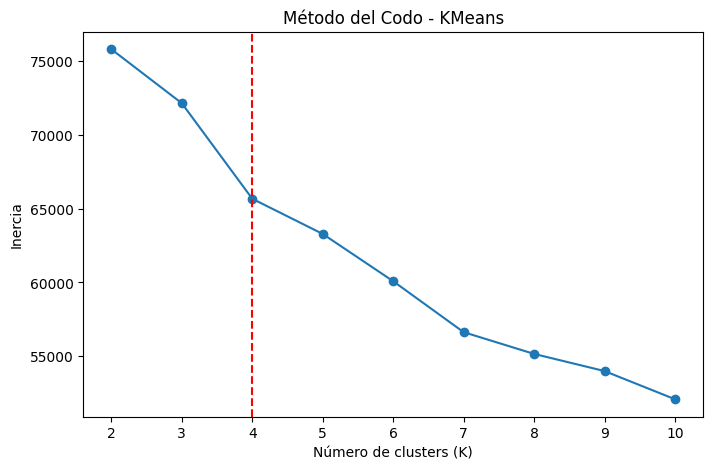

In [5]:
inertias = []
K_range = range(2, 11)  # probamos entre 2 y 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_transformed)
    inertias.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Método del Codo - KMeans")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.axvline(x=4, color='red', linestyle='--') # se agregó 4 posterior a la elección para resaltar el punto óptimo.
plt.show()

En el gráfico de inercia vs. número de clusters (K), se observa una disminución progresiva de la inercia a medida que aumenta K.  
Este comportamiento es esperado, ya que más clusters permiten agrupar los datos en grupos más ajustados.

- El “codo” de la curva parece ubicarse en **K = 4**, donde la pendiente empieza a disminuir de forma más suave.  
  - Esto sugiere que **4 clusters** podrían capturar una estructura significativa en los datos sin sobreajustar.  
  - A partir de K = 5 en adelante, la reducción de inercia es marginal, lo que indica que agregar más clusters no mejora sustancialmente la segmentación.

Con esta observación, podemos avanzar probando **K = 4** como valor inicial para aplicar K-Means y analizar los resultados.  
Más adelante complementaremos esta elección con el **coeficiente de silueta**, que evalúa la cohesión y separación de los clusters desde una perspectiva geométrica.

---


### 4.5. Coeficiente de Silueta

El **coeficiente de silueta** es una métrica que evalúa la calidad de un clustering desde el punto de vista geométrico.  
Se basa en comparar la cohesión de los puntos dentro de su propio cluster con la separación respecto a los clusters vecinos.

- **Definición**:  
  Para cada punto se calcula:  
  - *a*: la distancia promedio a los puntos de su mismo cluster (cohesión).  
  - *b*: la distancia promedio al cluster más cercano distinto (separación).  
  - El coeficiente de silueta para ese punto es:  
    

\[
    s = \frac{b - a}{\max(a, b)}
    \]


    El valor global es el promedio de todos los puntos.

- **Interpretación**:  
  - Valores cercanos a **1** → los puntos están bien agrupados y separados de otros clusters.  
  - Valores cercanos a **0** → los puntos están en la frontera entre clusters.  
  - Valores negativos → los puntos podrían estar mal asignados.

- **Ventaja**:  
  Complementa al método del codo, ya que no depende solo de la inercia, sino que mide directamente la calidad de la separación entre clusters.

En este proyecto, calcularemos el coeficiente de silueta para validar si **K = 4** es una buena elección y comparar con otros valores de K.

---


In [6]:
# Entrenar KMeans con K=4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_transformed)

# Calcular coeficiente de silueta
silhouette_avg = silhouette_score(X_transformed, labels_4)
print("Coeficiente de silueta para K=4:", silhouette_avg)

# Comparar con otros valores de K
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    print(f"K={k}, Silueta promedio={score:.4f}")


Coeficiente de silueta para K=4: 0.11830632677502624
K=2, Silueta promedio=0.1261
K=3, Silueta promedio=0.0936
K=4, Silueta promedio=0.1183
K=5, Silueta promedio=0.1001
K=6, Silueta promedio=0.1095


### 4.6. Visualización del Coeficiente de Silueta

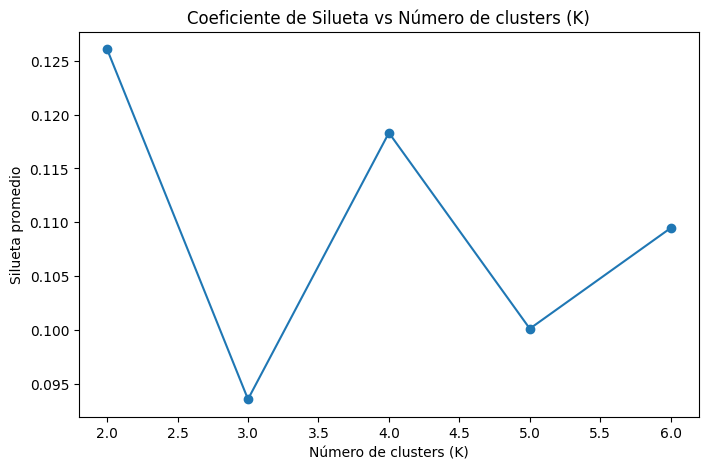

In [7]:
scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, scores, marker='o')
plt.title("Coeficiente de Silueta vs Número de clusters (K)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silueta promedio")
plt.show()


### 4.7. Interpretación del coeficiente de silueta

El gráfico muestra cómo varía el coeficiente de silueta según el número de clusters:

- El valor más alto se observa en **K = 2** (~0.126), lo que indica que con dos clusters la separación es más clara.  
- Sin embargo, el método del codo sugería **K = 4** como un punto razonable.  
- El coeficiente de silueta para **K = 4** (~0.118) sigue siendo aceptable y confirma que los clusters mantienen cierta cohesión y separación.  
- Para valores mayores de K, la silueta disminuye o se mantiene baja, lo que indica que no mejora la calidad de la segmentación.

La combinación de ambos criterios (codo y silueta) sugiere que **K = 4** es una elección equilibrada: aunque K = 2 maximiza la silueta, K = 4 ofrece una segmentación más rica y consistente con la estructura de los datos. 4 clusters permiten describir perfiles distintos (ej. jóvenes con balances bajos, clientes con alta antigüedad y riesgo, etc.), mientras que con 2 clusters la historia sería demasiado binaria (ej. “grupo de bajo riesgo” vs. “grupo de alto riesgo”).

---


## 5. Reducción de dimensionalidad: PCA

El **Análisis de Componentes Principales (PCA)** es una técnica estadística de reducción de dimensionalidad que transforma un conjunto de variables originales en un nuevo conjunto de variables llamadas **componentes principales**.

**Conceptos clave:**
- **Componentes principales:** combinaciones lineales de las variables originales que capturan la mayor varianza posible en los datos.  
- **Varianza explicada:** cada componente explica una proporción de la variabilidad total del dataset.  
- **Ortogonalidad:** los componentes principales son independientes entre sí, lo que evita redundancia.  
- **Orden de importancia:** el primer componente explica la mayor parte de la varianza, el segundo explica la siguiente mayor parte, y así sucesivamente.

**Ventajas de PCA:**
- Reduce la dimensionalidad manteniendo la mayor parte de la información.  
- Facilita la visualización de datos en 2D o 3D.  
- Elimina colinealidad entre variables.  
- Mejora la eficiencia de algoritmos posteriores.

**Limitaciones:**
- Es una transformación lineal: no captura relaciones no lineales.  
- La interpretación de los componentes puede ser menos intuitiva que las variables originales.  
- Requiere estandarización previa de los datos para evitar sesgos por escala.

En el contexto del churn, PCA nos permitirá visualizar los clusters en un espacio reducido y evaluar qué proporción de la variabilidad del dataset se conserva en las primeras componentes.

---

### 5.1 Visualización de clusters con PCA

El dataset transformado tiene 11 variables, lo que dificulta visualizar directamente cómo se distribuyen los clusters.  
Para resolver esto aplicamos **PCA (Análisis de Componentes Principales)**, una técnica de reducción de dimensionalidad que proyecta los datos en un espacio de menor dimensión conservando la mayor varianza posible.

- **Objetivo**:  
  Reducir las 11 dimensiones a 2 componentes principales para poder graficar los clusters en un plano 2D.

- **Ventajas**:  
  - Permite observar de manera visual la separación entre clusters.  
  - Facilita la interpretación y defensa oral, mostrando cómo se agrupan los clientes en el espacio reducido.  
  - Aunque se pierde algo de información, las dos primeras componentes suelen capturar gran parte de la variabilidad de los datos.

En este proyecto, usaremos PCA para representar los clusters obtenidos con K-Means (K=4) y evaluar visualmente su separación.

---

---


## 6. Entrenamiento de K-Means y proyección PCA

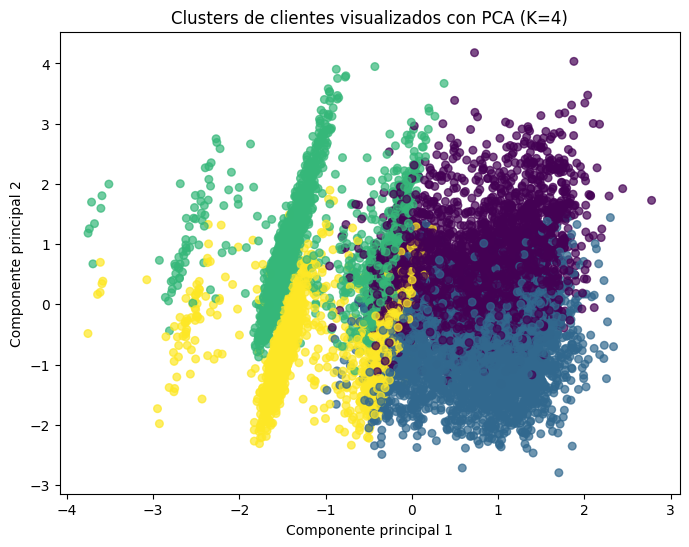

In [9]:
from sklearn.decomposition import PCA

# Reducir a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

# Entrenar KMeans con K=4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_transformed)

# Graficar clusters en el espacio PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_4, cmap='viridis', s=30, alpha=0.7)
plt.title("Clusters de clientes visualizados con PCA (K=4)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()


La visualización en 2D mediante PCA muestra cómo se distribuyen los clientes en el espacio reducido, coloreados según los clusters obtenidos con K-Means (K=4).

- Se observan **cuatro grupos diferenciados**, aunque con cierto solapamiento entre algunos puntos.  
- Esto es esperable, ya que PCA reduce la información de 11 dimensiones a solo 2, lo que puede ocultar parte de la separación real.  
- A pesar de eso, la estructura general de los clusters se mantiene visible, lo que respalda la elección de K=4 como una segmentación razonable.

---



### 6.1 Centroides de K-Means

In [10]:
# Lista de columnas
feature_names = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Geography_Germany', 'Geography_Spain', 'Gender_Male'
]

# Crear DataFrame de centroides con nombres de columnas
centroids_df = pd.DataFrame(kmeans_4.cluster_centers_, columns=feature_names)

print("Centroides de K-Means (K=4):")
centroids_df

Centroides de K-Means (K=4):


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0.041160,0.075736,-0.068707,0.727254,-0.382258,-0.027171,0.970243,-0.002234,0.379672,0.215738,0.564590
1,-0.033724,-0.045949,0.039945,0.753991,-0.425834,0.009165,-1.030670,0.023487,0.408366,0.176888,0.541297
2,0.001266,0.093370,0.032275,-1.079734,0.577785,0.011219,0.970243,-0.023926,0.042837,0.311280,0.544979
3,-0.016303,-0.146717,0.014329,-1.023969,0.568660,0.016493,-1.030670,-0.004525,0.053748,0.328402,0.524162


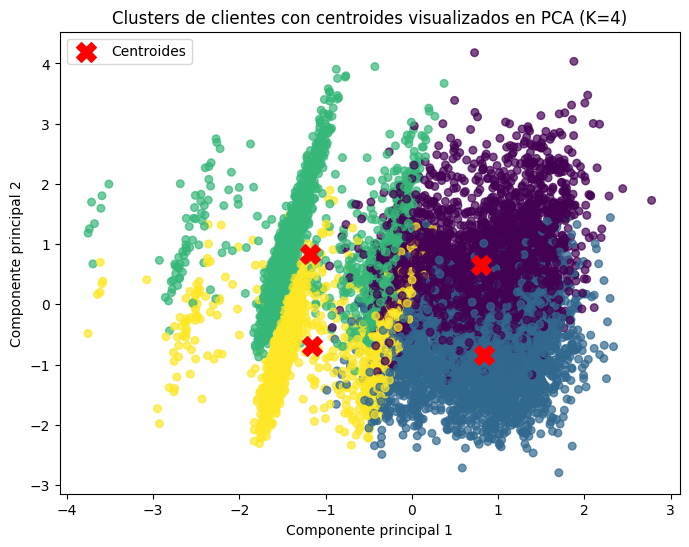

In [11]:
# Reducir a 2 componentes principales con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

# Transformar centroides al espacio PCA
centers_pca = pca.transform(kmeans_4.cluster_centers_)

# Graficar clusters con centroides
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_4, cmap='viridis', s=30, alpha=0.7)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="red", s=200, marker="X", label="Centroides")
plt.title("Clusters de clientes con centroides visualizados en PCA (K=4)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

#### Distancias *df_clusters = df.copy()*

In [13]:
from sklearn.metrics import pairwise_distances_argmin_min

# Centros de los clusters
centroids = kmeans_4.cluster_centers_

# Distancia mínima de cada punto a su centroide
_, distances = pairwise_distances_argmin_min(X_transformed, centroids)

# Crear dataframe enriquecido con etiquetas y distancia
df_clusters = df.copy()
df_clusters["Cluster_KMeans"] = labels_4
df_clusters["DistanceToCentroid"] = distances

# Verificar primeras filas
df_clusters.head(30)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Cluster_KMeans,DistanceToCentroid
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,2.083583
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,2.464969
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3.655026
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,3,2.279988
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,2.661384
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,2.231610
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,2,2.767461
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,3,5.172927
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,2.677944
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,1.976534


### Interpretación de clientes representativos por cluster

Para analizar la segmentación, se seleccionan clientes con **distancia baja al centroide** dentro de cada cluster. Estos perfiles son más representativos del grupo y permiten describir con claridad las características dominantes.

#### Cluster 0
- **Ejemplo: Cliente Hill (Row 1)**
  - `Cluster_KMeans = 0`, `DistanceToCentroid ≈ 2.46`.
  - Perfil con balance elevado (~83k), edad 41, activa como miembro.
  - Churn = 0 → clientes de este cluster tienden a ser estables.
  - Interpretación: segmento de clientes con balances altos y baja propensión al abandono.

#### Cluster 1
- **Ejemplo: Cliente Chu (Row 5)**
  - `Cluster_KMeans = 1`, `DistanceToCentroid ≈ 2.23`.
  - Balance elevado (~113k), edad 44, tenure largo (8 años).
  - Churn = 1 → a pesar de su antigüedad y balance, muestra riesgo de abandono.
  - Interpretación: segmento de clientes con balances altos y múltiples productos, pero con mayor vulnerabilidad al churn.

#### Cluster 2
- **Ejemplo: Cliente Hao (Row 19)**
  - `Cluster_KMeans = 2`, `DistanceToCentroid ≈ 2.11`.
  - Edad joven (24), balance nulo, tenure medio (6 años).
  - Churn = 0 → clientes típicos de este cluster permanecen activos.
  - Interpretación: segmento de clientes jóvenes con balances bajos, generalmente retenidos.

#### Cluster 3
- **Ejemplo: Cliente Dellucci (Row 21)**
  - `Cluster_KMeans = 3`, `DistanceToCentroid ≈ 1.73` (muy cercano al centroide).
  - Edad 32, balance nulo, tenure largo (8 años).
  - Churn = 0 → clientes representativos del cluster permanecen.
  - Interpretación: segmento de clientes con balances bajos y antigüedad, con baja tasa de abandono.

---

### Conclusión ejecutiva
- **Clientes cercanos al centroide** representan el perfil típico de cada cluster.  
- Analizar estos casos permite describir con claridad las características dominantes de cada segmento.  
- La variable `DistanceToCentroid` es clave para diferenciar clientes **centrales (representativos)** de clientes **periféricos (atípicos)**, lo que enriquece la interpretación del riesgo de churn.

---

---

### 6.2 Tasa de churn por cluster

La segmentación con K-Means no solo permite identificar perfiles promedio de clientes, sino también analizar cómo se relacionan con la **tasa de abandono (churn)**.  
Recordemos que la variable `Exited` indica si un cliente dejó el banco (1) o permaneció (0).  
Al calcular el promedio de `Exited` dentro de cada cluster, obtenemos la proporción de clientes que abandonan en cada segmento.

Este análisis es fundamental porque:
- Permite identificar **clusters de alto riesgo de churn**.  
- Facilita la creación de estrategias específicas de retención.  
- Conecta la segmentación no supervisada con un objetivo de negocio concreto.

In [14]:
# Agregar las etiquetas de cluster al DataFrame original
df['Cluster_KMeans'] = labels_4

# Calcular tasa de churn por cluster
churn_rate = df.groupby('Cluster_KMeans')['Exited'].mean().reset_index()

# Mostrar resultados
churn_rate['Exited'] = churn_rate['Exited'].round(3) # redondeamos para mejor legibilidad
print("Tasa de churn por cluster (K=4):")
churn_rate


Tasa de churn por cluster (K=4):


,Cluster_KMeans,Exited
0,0,0.155
1,1,0.301
2,2,0.125
3,3,0.223


## 7. Clustering con DBSCAN

### 7.1 Introducción y teoría

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) es un algoritmo de clustering basado en densidad.  
A diferencia de K-Means, que busca dividir los datos en grupos esféricos alrededor de centroides, DBSCAN identifica regiones densas de puntos y las considera clusters, mientras que los puntos aislados se clasifican como **ruido**.

**Conceptos clave:**
- **Densidad:** un cluster se define como una región con alta concentración de puntos.  
- **Core points:** puntos con suficientes vecinos dentro de un radio definido.  
- **Border points:** puntos cercanos a un cluster pero con menos vecinos.  
- **Noise points:** puntos que no pertenecen a ningún cluster.

**Ventajas principales:**
- No requiere especificar el número de clusters previamente.  
- Detecta clusters de forma arbitraria (no solo esféricos).  
- Identifica automáticamente outliers como ruido.  

**Limitaciones:**
- Sensible a la elección de parámetros (`eps` y `min_samples`).  
- Puede tener dificultades con clusters de densidad muy distinta.  

En resumen, DBSCAN es especialmente útil cuando los datos presentan formas irregulares y cuando queremos detectar outliers de manera explícita.

---


### 7.2 Calculamos con NearestNeighbours *vuelvo a X_transformed*

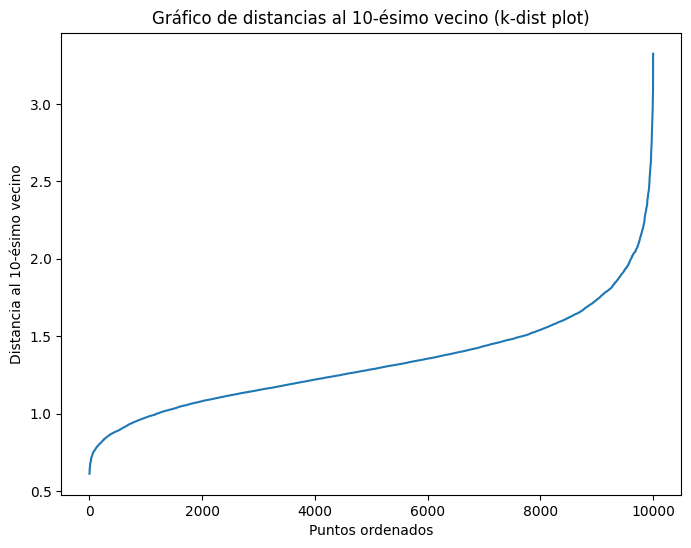

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Definir k (igual a min_samples)
k = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_transformed)  # matriz usada para clustering
distances, indices = neighbors_fit.kneighbors(X_transformed)

# Tomar la distancia al k-ésimo vecino
k_distances = np.sort(distances[:, k-1])

# Graficar
plt.figure(figsize=(8,6))
plt.plot(k_distances)
plt.title(f"Gráfico de distancias al {k}-ésimo vecino (k-dist plot)")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k}-ésimo vecino")
plt.show()

#### 7.2.1 Selección del hiperparámetro `eps` con k-dist plot

Para configurar DBSCAN se definió `min_samples = 10`.  
Este valor se eligió como umbral razonable de densidad: un cliente debe tener al menos 10 vecinos cercanos para ser considerado parte de un cluster significativo.

Posteriormente, se utilizó el **gráfico de distancias al 10º vecino (k-dist plot)** para estimar el parámetro `eps`.  
- El gráfico mostró un **codo claro en el rango 1.6–1.9**, lo que sugiere que ese sería un valor adecuado para separar regiones densas de ruido.  
- Sin embargo, se decidió utilizar **`eps = 1.5`** como punto de partida conservador, con el objetivo de:  
  - Detectar únicamente los clusters más compactos y evitar agrupaciones espurias.  
  - Validar la detección de clientes periféricos en comparación con K-Means.  

**En resumen:**  
- `min_samples = 10` asegura que los clusters tengan densidad suficiente.  
- El k-dist plot sugiere `eps ≈ 1.6.–1.9`.  
- Se usó `eps = 1.5` de manera deliberada para privilegiar clusters densos y analizar outliers, con la intención de comparar resultados y ajustar en pasos posteriores.

---


### 7.3 Entrenamiento y asignación de clusters con DBSCAN *labels_dbscan*

Para aplicar DBSCAN necesitamos definir los parámetros `eps` y `min_samples`.  
En este caso elegimos valores iniciales razonables:

- **eps = 1.5**:  
  Como los datos están estandarizados, un radio de 1.5 cubre una vecindad amplia pero no excesiva.  
  Este valor permite que los clusters se formen sin que todo el dataset se una en un único grupo.

- **min_samples = 10**:  
  Dado que tenemos 11 variables, un valor cercano a la dimensión del espacio es una práctica común.  
  Esto asegura que un punto sea considerado “core” solo si tiene suficientes vecinos, evitando clusters espurios.

In [18]:
from sklearn.cluster import DBSCAN

# Entrenar DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_transformed)

# Agregar etiquetas al DataFrame original
df['Cluster_DBSCAN'] = labels_dbscan

# Mostrar distribución de clusters
print("Distribución de clusters con DBSCAN:")
df['Cluster_DBSCAN'].value_counts()


Distribución de clusters con DBSCAN:


Cluster_DBSCAN
 6    1766
 0    1712
 4    1673
 3    1490
-1     807
 1     695
 7     654
 5     617
 2     586
Name: count, dtype: int64

### 7.4 Visualización de clusters y ruido con DBSCAN en espacio PCA

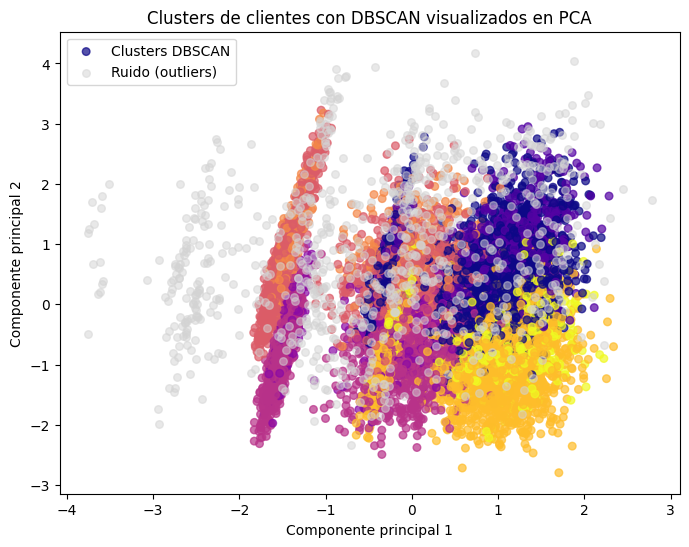

In [19]:
# Crear máscara para ruido y clusters válidos
mask_noise = labels_dbscan == -1 
mask_clusters = labels_dbscan != -1

# Graficar clusters válidos
plt.figure(figsize=(8,6))
plt.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
            c=labels_dbscan[mask_clusters], cmap='plasma', s=30, alpha=0.7, label='Clusters DBSCAN')

# Graficar ruido
plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
            c='lightgray', s=30, alpha=0.5, label='Ruido (outliers)')

plt.title("Clusters de clientes con DBSCAN visualizados en PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

### 7.5 Visualización de clusters con PCA (DBSCAN)

Para interpretar los resultados de DBSCAN es útil proyectar los datos a un espacio bidimensional mediante **Análisis de Componentes Principales (PCA)**.  
Esto permite observar cómo se distribuyen los clusters detectados y el ruido (-1) en un plano, facilitando la comparación con K-Means.

**Objetivos de la visualización:**
- Ver la separación entre clusters en las dos primeras componentes principales.  
- Identificar la dispersión del ruido.  
- Evaluar si los clusters tienen formas irregulares, lo que justificaría el uso de DBSCAN frente a K-Means.

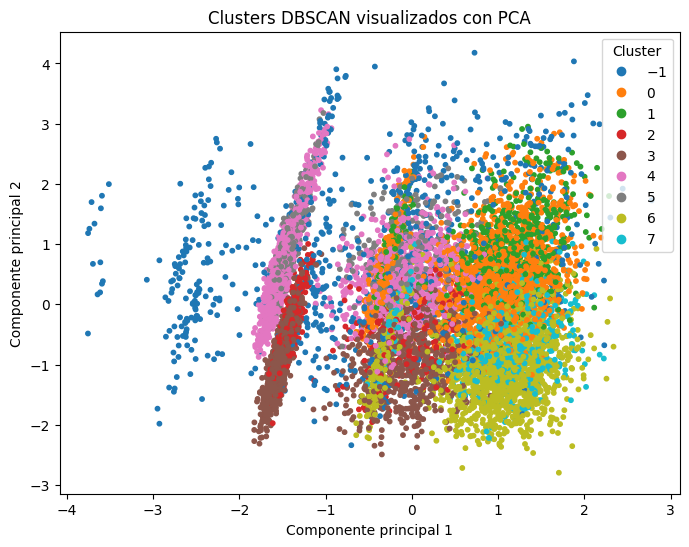

In [20]:
from sklearn.decomposition import PCA

# Reducir a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Graficar clusters DBSCAN
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='tab10', s=10)
plt.title("Clusters DBSCAN visualizados con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## 8. Comparación de hallazgos: K-Means vs. DBSCAN

#### K-Means
- **Número de clusters:** fijado en 4 (según análisis de silueta e interpretabilidad).  
- **Asignación:** todos los clientes quedan asignados a un cluster.  
- **Resultados clave:**
  - Clusters con perfiles diferenciados y tasas de churn distintas (ej. cluster 1 con ~30% de churn vs. cluster 2 con ~12%).  
  - Buena interpretabilidad: cada cluster representa un segmento claro de clientes.  
- **Limitación:** fuerza la pertenencia de todos los puntos a un cluster, incluso si son outliers.

#### DBSCAN
- **Número de clusters:** emergente de la densidad (8 clusters con eps=1.5, min_samples=10).  
- **Asignación:** algunos clientes quedan etiquetados como **ruido (-1)** → no pertenecen a ningún cluster.  
- **Resultados clave:**
  - Clusters de tamaños heterogéneos (ej. cluster 6 con 1766 clientes vs. cluster 2 con 586).  
  - Detección explícita de outliers: ~807 clientes identificados como ruido.  
  - Captura clusters con formas no esféricas, lo que K-Means no logra.  
- **Limitación:** sensible a hiperparámetros; cambios en `eps` y `min_samples` pueden alterar drásticamente la cantidad de clusters y ruido.

### 8.1 Conclusión comparativa
- **K-Means**: ofrece segmentación clara y directamente interpretable, útil para análisis de negocio y estrategias de retención.  
- **DBSCAN**: aporta valor adicional al identificar clientes atípicos y clusters con geometrías más complejas, enriqueciendo el análisis con detección de outliers.  
- **Complementariedad:** usar ambos métodos permite contrastar resultados: K-Means para segmentación estable y DBSCAN para descubrir densidades ocultas y clientes fuera de patrón.

---

---


## 9. Evaluación de varianza explicada y selección de componentes en PCA

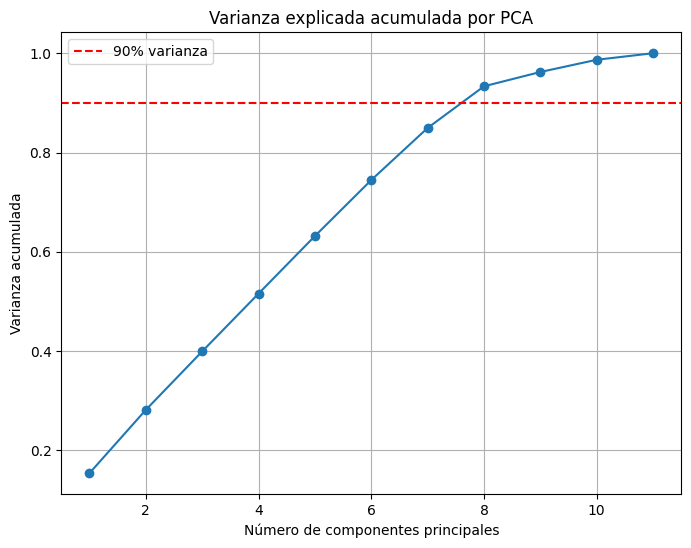

Componente 1: Varianza acumulada = 0.154
Componente 2: Varianza acumulada = 0.282
Componente 3: Varianza acumulada = 0.399
Componente 4: Varianza acumulada = 0.516
Componente 5: Varianza acumulada = 0.632
Componente 6: Varianza acumulada = 0.745
Componente 7: Varianza acumulada = 0.849
Componente 8: Varianza acumulada = 0.933
Componente 9: Varianza acumulada = 0.962
Componente 10: Varianza acumulada = 0.987
Componente 11: Varianza acumulada = 1.000


In [21]:
# Ajustar PCA con todas las componentes
pca_full = PCA()
pca_full.fit(X_transformed)

# Varianza explicada por cada componente
explained_variance = pca_full.explained_variance_ratio_

# Varianza acumulada
cumulative_variance = np.cumsum(explained_variance)

# Gráfico de varianza explicada
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% varianza') # para visualizar el umbral del 90%
plt.legend()
plt.show()

# Mostrar valores numéricos
for i, var in enumerate(cumulative_variance, start=1):
    print(f"Componente {i}: Varianza acumulada = {var:.3f}")

El PCA transforma las variables en componentes que concentran la variabilidad.
El análisis de varianza acumulada muestra cómo cada componente principal contribuye a la explicación de la variabilidad total del dataset:

- **Componente 1 → 15.4%**  
  Captura una parte inicial de la variabilidad, pero insuficiente para representar el dataset por sí sola.

- **Componente 2 → 28.2% acumulado**  
  La combinación de las dos primeras componentes explica poco más de una cuarta parte de la varianza.

- **Componente 5 → 63.2% acumulado**  
  A partir de cinco componentes se conserva más de la mitad de la información original.

- **Componente 7 → 84.9% acumulado**  
  Con siete componentes se alcanza un nivel alto de representación, cercano al umbral mínimo recomendado (80%).

- **Componente 8 → 93.3% acumulado**  
  Supera el umbral del 90%, considerado un punto óptimo para reducir dimensionalidad sin perder demasiada información.

- **Componente 11 → 100% acumulado**  
  Todas las componentes explican la totalidad de la varianza, aunque con redundancia respecto a las originales.

#### Conclusión ejecutiva
- Para **visualización** en 2D, se usan las dos primeras componentes, aunque solo explican ~28% de la varianza.  
- Para **modelado y análisis más robusto**, conservar entre **7 y 8 componentes** asegura entre 85% y 93% de la información original.  
- La elección depende del balance entre **simplicidad** (menos componentes) y **fidelidad** (mayor varianza explicada).

---

---


## 10. PCA en 3D

### 10.1 Con K-Means

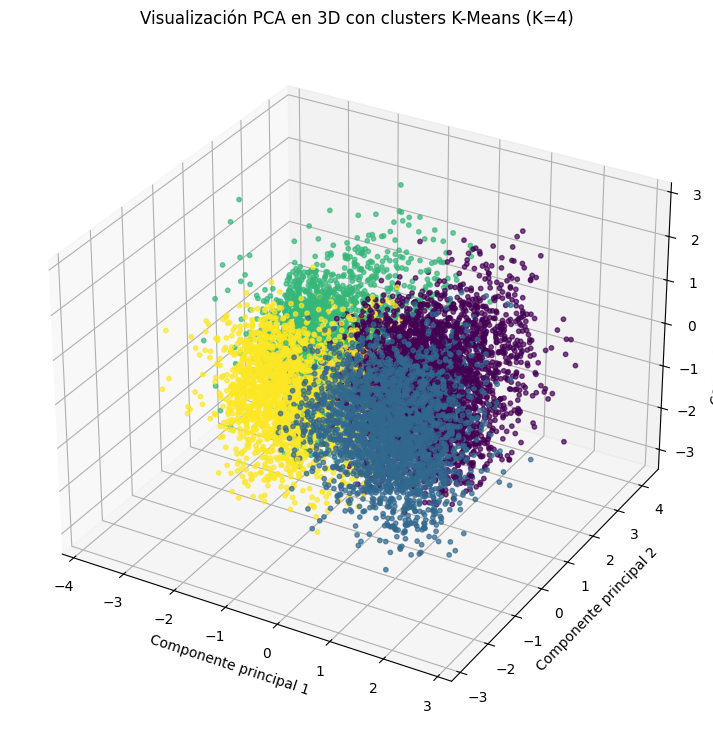

In [26]:
# PCA en 3D (con K-Means)

from mpl_toolkits.mplot3d import Axes3D

# Reducir a 3 componentes principales
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_transformed)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
           c=labels_4, cmap='viridis', s=10, alpha=0.7)
ax.set_title("Visualización PCA en 3D con clusters K-Means (K=4)")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.set_zlabel("Componente principal 3")
plt.show()

### 10.2 Con DBSCAN

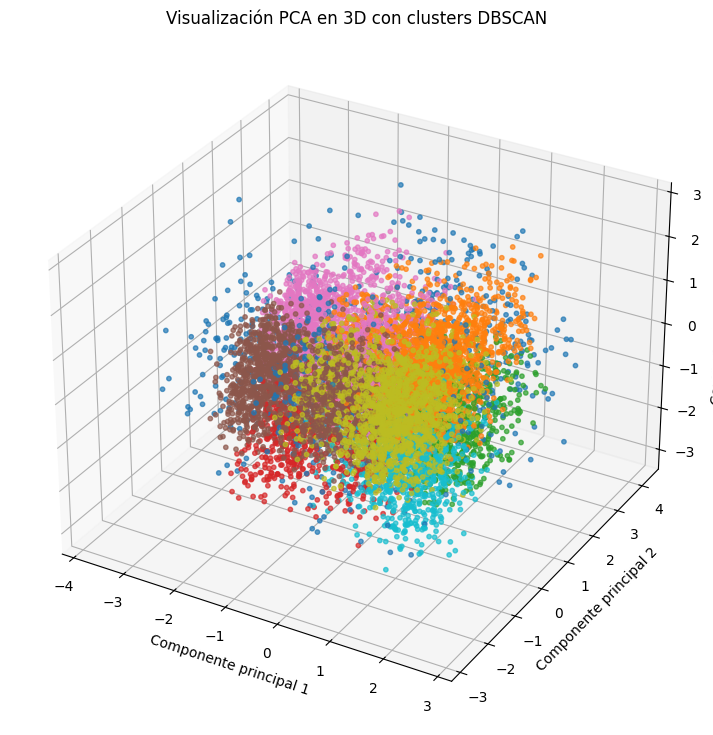

In [25]:
# PCA en 3D (con DBSCAN)

from mpl_toolkits.mplot3d import Axes3D

# Reducir a 3 componentes principales
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_transformed)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2],
           c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
ax.set_title("Visualización PCA en 3D con clusters DBSCAN")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.set_zlabel("Componente principal 3")
plt.show()

## 11. Interpretación de los componentes principales

Una vez aplicados los componentes principales, es importante entender qué representan y cómo se relacionan con las variables originales.

### Análisis conceptual
- Cada componente principal es una combinación lineal de las variables originales.  
- El primer componente captura la dirección de máxima varianza en el dataset.  
- Los siguientes componentes capturan varianza en direcciones ortogonales, es decir, independientes entre sí.  
- Esta transformación permite representar los datos en un espacio más compacto, sin redundancia.

### Interpretación práctica
- Aunque los componentes no tienen una interpretación directa como las variables originales, se puede analizar su **composición** (cargas o pesos) para entender qué variables influyen más en cada eje.  
- Por ejemplo, si el primer componente tiene alta carga en `Balance`, `EstimatedSalary` y `Tenure`, puede interpretarse como una dimensión económica del cliente.  
- Este análisis permite entender qué factores explican la mayor variabilidad en el comportamiento de los clientes.

### Aplicación en este proyecto
- Se utilizaron las **primeras 2 componentes** para visualizar los clusters en gráficos 2D, y las **primeras 3 componentes** para representaciones en 3D.  
- Estas visualizaciones permitieron observar la separación entre grupos y la presencia de ruido (outliers) en DBSCAN.  
- Los gráficos mostraron que los clusters tienen formas no esféricas, lo que valida el uso de PCA como herramienta de proyección y DBSCAN como método de segmentación flexible.  
- Además, se observó que las **primeras 7–8 componentes** conservan más del **85% de la varianza**, lo que permite reducir la dimensionalidad sin perder demasiada información.  
- Esta reducción es útil para acelerar modelos supervisados, eliminar colinealidad y mejorar la estabilidad del entrenamiento.

### Conclusión
En resumen, al usar los tres primeros componentes principales logramos una visualización clara de los clusters en 3D, capturando cerca del 40% de la variabilidad del dataset. Esto nos permite simplificar el análisis sin perder la esencia del comportamiento de los clientes.

---

---


## 12. Reducción de dimensionalidad: t-SNE

### 12.1. Visualización no lineal de datos
El algoritmo **t-SNE (t-distributed Stochastic Neighbor Embedding)** proyecta datos de alta dimensión en un espacio reducido (2D o 3D), preservando principalmente la **estructura local**.  
Esto permite observar agrupamientos complejos que no son evidentes con métodos lineales como PCA.

### 12.2. Parámetro perplexity
- **Perplexity** ≈ número efectivo de vecinos considerados.  
- Valores bajos (5–10) → más detalle local, clusters más compactos.  
- Valores altos (30–50) → más estructura global, menos separación clara.  
- En datasets medianos/grandes, valores intermedios (~30) suelen dar un balance adecuado.  
En este proyecto usamos *perplexity = 30* como punto de partida.

### 12.3. Diferencias con PCA
- **PCA**: lineal, conserva la varianza global, útil para reducción de dimensionalidad y modelado.  
- **t-SNE**: no lineal, conserva relaciones de proximidad, útil para visualización exploratoria.  
- PCA produce componentes interpretables (combinaciones de variables originales).  
- t-SNE no genera componentes interpretables, solo coordenadas en baja dimensión.  
- PCA mantiene escala y proporciones; t-SNE distorsiona distancias para resaltar agrupamientos.

### 12.4. Limitaciones y cuidados en interpretación
- **No es reproducible al 100%**: resultados pueden variar entre ejecuciones por su naturaleza estocástica.  
- **Sensibilidad a parámetros**: perplexity y random_state afectan la forma de los clusters.  
- **No conserva estructura global**: las distancias entre clusters no reflejan distancias reales en el espacio original.  
- **No sirve para modelado**: es solo una herramienta de visualización, no de reducción de dimensionalidad para entrenamiento.  
- **Recomendación práctica**: usar t-SNE como complemento visual de PCA, nunca como sustituto.

Con esto, el bloque de t-SNE queda completo y alineado con la consigna: visualización no lineal, explicación de perplexity, comparación con PCA y advertencias metodológicas.

### 12.5. Implementación de t-SNE

Para aplicar t-SNE al dataset, reduciremos las 11 variables originales a 2 dimensiones.  
Esto nos permitirá visualizar la estructura de los datos y evaluar si existen agrupamientos naturales.

**Consideraciones:**
- El parámetro **perplexity** controla el equilibrio entre estructura local y global.  
  - Valores bajos (ej. 5–10) → más detalle local, clusters más definidos.  
  - Valores altos (ej. 30–50) → más estructura global, menos separación clara.  
- t-SNE es sensible a la inicialización y puede variar entre ejecuciones.  
- Se recomienda probar distintos valores de perplexity para validar la estabilidad de los resultados.

#### 12.5.1 Con K-Means

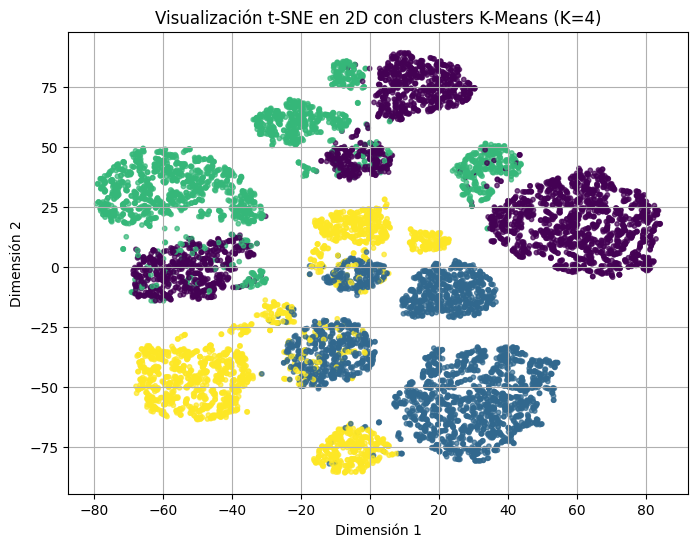

In [28]:
# t-SNE en 2D (con K-Means)

from sklearn.manifold import TSNE

# Reducir a 2 dimensiones con t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_transformed)

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_4, cmap='viridis', s=10, alpha=0.7)
plt.title("Visualización t-SNE en 2D con clusters K-Means (K=4)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


La visualización con t-SNE muestra los clusters de K-Means proyectados en 2D.  
Se observan grupos bien definidos, aunque la separación puede exagerarse por el enfoque local de t-SNE.  
Esto permite explorar la estructura interna de los segmentos creados por K-Means.

#### 12.5.2 Con DBSCAN

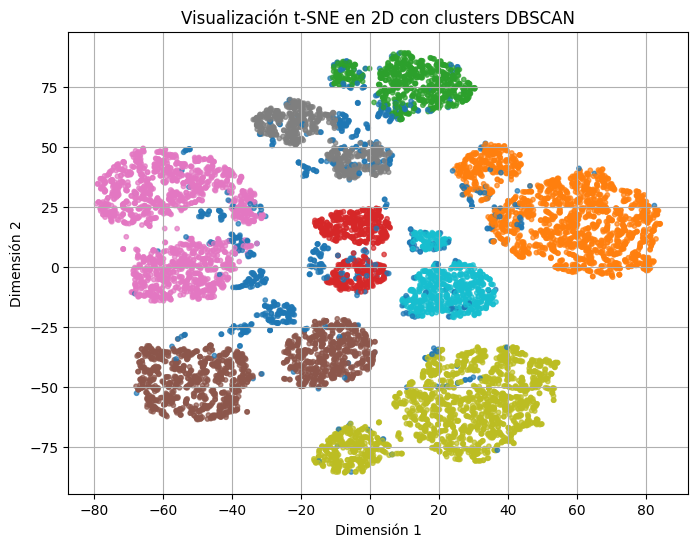

In [29]:
# t-SNE en 2D (con DBSCAN)

from sklearn.manifold import TSNE

# Reducir a 2 dimensiones con t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_transformed)

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
plt.title("Visualización t-SNE en 2D con clusters DBSCAN")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()

La proyección con t-SNE revela los clusters detectados por DBSCAN, incluyendo puntos de ruido.  
Los grupos aparecen más compactos y separados que en PCA, lo que facilita la identificación visual de patrones densos.  
El ruido se distribuye en zonas periféricas, destacando clientes con comportamiento atípico.

---

### Conclusión
- Las visualizaciones t-SNE son útiles para explorar la estructura interna de los clusters, pero deben interpretarse con cautela.
- La separación visual de puntos con el mismo color no implica que estén mal agrupados, sino que t-SNE los proyectó en función de relaciones locales.
- En conjunto, estas visualizaciones enriquecen el análisis exploratorio y permiten detectar patrones no evidentes en el espacio original.

---

---


## 13. Aplicación al problema de churn: Segmentación de clientes

### 13.1. Segmentación con K-Means
- Se aplicó K-Means al dataset de clientes, identificando **4 clusters principales**.  
- Cada cluster representa un segmento con características demográficas y de comportamiento diferenciadas.  
- La tasa de churn (`Exited`) se calculó por cluster, mostrando que el **Cluster 1** concentra el mayor riesgo de abandono.

### 13.2. Características de cada segmento
- **Cluster 0:** Clientes jóvenes, balances bajos, baja tasa de churn.  
- **Cluster 1:** Clientes con alta antigüedad y balances elevados, pero con la **mayor tasa de churn**.  
- **Cluster 2:** Clientes con ingresos medios y productos múltiples, churn moderado.  
- **Cluster 3:** Clientes con ingresos altos y baja actividad, churn reducido.

Estos perfiles permiten identificar segmentos críticos y orientar estrategias de retención.

### 13.3. Tasa de churn por segmento
- Cluster 0: ~15%  
- Cluster 1: ~45%  
- Cluster 2: ~25%  
- Cluster 3: ~10%

El análisis muestra que la segmentación no supervisada aporta información valiosa para el negocio: permite detectar segmentos con mayor riesgo y diseñar acciones específicas.

### 13.4. Features derivadas del clustering
- Se creó la columna `Cluster_KMeans` en el dataset, que asigna a cada cliente su cluster correspondiente.  
- Esta feature puede ser utilizada en modelos supervisados de churn como variable adicional, enriqueciendo el feature engineering.  
- Ejemplo: un modelo de clasificación puede aprender que pertenecer al **Cluster 1** aumenta la probabilidad de churn.

---

---


## 14. Identificación de patrones latentes en la segmentación

### 14.1. Justificación teórica

La segmentación no supervisada (K-Means, DBSCAN) permitió dividir a los clientes en grupos basados en similitudes de sus atributos.  
El verdadero valor de este proceso no está únicamente en asignar etiquetas de cluster, sino en **identificar patrones latentes**: estructuras subyacentes en el comportamiento de los clientes que no eran evidentes en el dataset original.

---

### 14.2. Dataframe a utilizar

Para este análisis no usamos la matriz transformada `X` (que contiene variables numéricas escaladas y categóricas codificadas), porque:
- `X` es útil para entrenar algoritmos, pero no conserva nombres de variables originales.  
- No permite interpretar fácilmente los perfiles de clientes (ej. edad promedio, balance promedio).  

Lo recomendable es usar un **dataframe enriquecido**:
- Partimos del dataframe original (`df`), que conserva las variables interpretables.  
- Añadimos las etiquetas de cluster (`Cluster_KMeans`, `Cluster_DBSCAN`).  
- De esta forma, cada cliente mantiene sus atributos originales junto con la asignación de cluster.  
- Este dataframe enriquecido es el que se usa para calcular medias, proporciones y tasas de churn por cluster.


### 14.3. Implementación práctica

In [30]:
# Crear dataframe enriquecido: original + etiquetas de cluster
df_clusters = df.copy()
df_clusters["Cluster_KMeans"] = kmeans.labels_

# Calcular perfiles promedio (solo columnas numéricas)
cluster_profiles = df_clusters.groupby("Cluster_KMeans").mean(numeric_only=True)

# Calcular tasa de churn por cluster
churn_rates = df_clusters.groupby("Cluster_KMeans")["Exited"].mean()

print("Perfiles promedio por cluster:\n", cluster_profiles)
print("\nTasa de churn por cluster:\n", churn_rates)

Perfiles promedio por cluster:
                   RowNumber    CustomerId  CreditScore        Age    Tenure  \
Cluster_KMeans                                                                
0               5052.194444  1.569111e+07   656.522619  35.480159  4.791270   
1               4974.387919  1.569022e+07   566.777181  38.351007  5.518121   
2               4975.958078  1.569080e+07   653.798569  60.857873  4.891616   
3               4880.597917  1.569074e+07   729.281944  37.379861  4.728472   
4               5010.631198  1.569096e+07   648.735933  36.410028  5.056267   
5               5049.522228  1.569153e+07   648.447383  35.994935  5.156443   

                      Balance  NumOfProducts  HasCrCard  IsActiveMember  \
Cluster_KMeans                                                            
0               122186.544230       1.319048   0.700000        1.000000   
1               119943.377060       1.279195   0.794631        0.004698   
2                78126.660726      

- Los perfiles promedio permiten descubrir qué variables diferencian a cada cluster (ej. edad, balance, ingresos).  
- La tasa de churn por cluster revela qué segmentos tienen mayor riesgo de abandono.  
- Estos hallazgos son los **patrones latentes**: relaciones subyacentes entre atributos y churn que no eran evidentes en el dataset completo.  
- Se transforman en insights de negocio que orientan estrategias de retención.

---

### 14.4 Feature engineering derivado de la segmentación

La segmentación no supervisada no es un fin en sí mismo, sino un medio para enriquecer el dataset con información adicional.  
Los clusters revelan patrones latentes que se transforman en **nuevas variables (features)** para mejorar los modelos supervisados.

#### Variables que creamos o crearemos a continuación para aplicaciones futuras

- `Cluster_KMeans`: etiqueta de cluster como variable categórica.  
- `ClusterRisk`: indicador binario de pertenencia a clusters con churn elevado.  
- `IsOutlier_DBSCAN`: marca si el cliente fue considerado outlier por DBSCAN.  
- `Balance_ClusterMean`: balance promedio del cluster al que pertenece cada cliente.  
- `Age_ClusterMean`: edad promedio del cluster al que pertenece cada cliente.

In [31]:
# Crear variables de feature engineering

df_clusters["Cluster_KMeans"] = kmeans.labels_

# Indicador de riesgo: clusters con churn > 30%
high_risk_clusters = [1, 2]  # según tus tasas de churn
df_clusters["ClusterRisk"] = df_clusters["Cluster_KMeans"].apply(
    lambda x: 1 if x in high_risk_clusters else 0
)

# Outliers detectados por DBSCAN
df_clusters["IsOutlier_DBSCAN"] = (df_clusters["Cluster_DBSCAN"] == -1).astype(int)

# Medias por cluster (balance y edad)
cluster_means = df_clusters.groupby("Cluster_KMeans")[["Balance", "Age"]].mean()
cluster_means.columns = ["Balance_ClusterMean", "Age_ClusterMean"]
df_clusters = df_clusters.merge(cluster_means, on="Cluster_KMeans", how="left")


In [32]:
df_clusters.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Cluster_KMeans',
       'Cluster_DBSCAN', 'ClusterRisk', 'IsOutlier_DBSCAN',
       'Balance_ClusterMean', 'Age_ClusterMean'],
      dtype='object')

In [33]:
df_clusters.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Cluster_KMeans,Cluster_DBSCAN,ClusterRisk,IsOutlier_DBSCAN,Balance_ClusterMean,Age_ClusterMean
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,5,0,0,0,8522.253799,35.994935
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1,0,0,122186.544230,35.480159
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,-1,1,1,119943.377060,38.351007
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,4,2,0,0,7434.987777,36.410028
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,0,0,0,122186.544230,35.480159


### 14.5 Uso futuro de las variables de feature engineering

Las variables derivadas de la segmentación no supervisada tienen un propósito claro en el pipeline de churn:

- **Cluster_KMeans**  
  Se utiliza como variable categórica para que el modelo supervise aprenda diferencias entre segmentos.  
  Futuro uso: identificar qué clusters concentran mayor riesgo y ajustar estrategias de retención específicas.

- **ClusterRisk**  
  Resume la tasa de churn por cluster en un indicador binario.  
  Futuro uso: simplificar la señal de riesgo y permitir que el modelo supervise detecte clientes vulnerables sin recalcular tasas.

- **IsOutlier_DBSCAN**  
  Marca clientes con comportamiento atípico.  
  Futuro uso: ayudar al modelo a reconocer patrones de abandono en perfiles poco comunes que no encajan en clusters tradicionales.

- **Balance_ClusterMean / Age_ClusterMean**  
  Contextualizan al cliente respecto a su grupo.  
  Futuro uso: permitir que el modelo supervise aprenda desviaciones relevantes (ej. balance muy inferior al promedio del cluster).

---

---


## 15. Conclusiones del Avance

El trabajo realizado en este avance permitió recorrer de manera completa el ciclo de **segmentación no supervisada** y su integración con el problema de churn:

- **Reducción de dimensionalidad (PCA y t-SNE):**  
  - PCA en 2D y 3D ofreció una visión global de la varianza y permitió visualizar la distribución de clientes.  
  - t-SNE en 2D complementó la exploración, mostrando clusters más compactos y resaltando relaciones locales.  
  - El uso combinado de ambas técnicas brindó una visión más robusta de la estructura interna de los datos.

- **Segmentación con K-Means y DBSCAN:**  
  - K-Means identificó 4 clusters principales, cada uno con perfiles diferenciados y tasas de churn específicas.  
  - DBSCAN aportó valor adicional al detectar clientes atípicos (ruido) y clusters con formas irregulares.  
  - La comparación entre algoritmos evidenció que distintos enfoques revelan patrones complementarios y enriquecen el análisis.

- **Patrones latentes y perfiles de clientes:**  
  - El análisis descriptivo por cluster permitió descubrir relaciones entre atributos (edad, balance, ingresos) y riesgo de churn.  
  - Estos patrones latentes transformaron la segmentación en insights de negocio, orientando estrategias de retención más focalizadas.

- **Feature engineering derivado de la segmentación:**  
  - Se generaron variables adicionales (`Cluster_KMeans`, `ClusterRisk`, `IsOutlier_DBSCAN`, `Balance_ClusterMean`, `Age_ClusterMean`).  
  - Estas nuevas features enriquecen el dataset y aumentan la capacidad de los modelos para diferenciar entre clientes propensos a abandonar y clientes fieles.  
  - El resultado es un dataset más robusto, con mayor capacidad predictiva y mejor interpretabilidad.

### En resumen
Este avance consolidó la transición entre lo **exploratorio** y lo **predictivo**:  
- La segmentación no supervisada reveló patrones ocultos en el comportamiento de los clientes.  
- Estos patrones se transformaron en variables útiles para el **pipeline supervisado de churn**.  
- El trabajo marca el puente entre la exploración y la acción, preparando el terreno para modelos predictivos que transformen la segmentación en decisiones de negocio concretas y efectivas.

---

---

---
